In [3]:
# ================================================================
#  PHASE 6 — TESTING THE LINE ASSUMPTIONS
#  Notebook : notebooks/06_assumption_testing.ipynb
#
#  Linear Regression makes 5 assumptions about your data.
#  If these are violated, your model's predictions can still
#  "work" but your p-values, confidence intervals, and trust
#  in coefficients become unreliable.
#
#  L — Linearity      : relationship between X and y is a straight line
#  I — Independence   : residuals don't depend on each other
#  N — Normality      : residuals are normally distributed
#  E — Equal Variance : residuals have constant spread (homoscedasticity)
#
#  We test each one with a plot AND a statistical test.
# ================================================================
 
 
# ── CELL 1 — Imports ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
 
print("Imports done ✓")
 
 

Imports done ✓


In [4]:
# We reuse the same Multiple LR model from Phase 5.
# (Re-fitting here keeps this notebook independent and runnable on its own)
 
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
X_train = train.drop(columns=['SalePrice'])
X_test  = test.drop(columns=['SalePrice'])
y_train = train['SalePrice'].values
y_test  = test['SalePrice'].values
 
model = LinearRegression()
model.fit(X_train, y_train)
 
# Predictions on test set — we test assumptions using test residuals
y_pred = model.predict(X_test)
 
# Residual = actual - predicted  (this is what we test in every assumption)
residuals = y_test - y_pred
 
print(f"Model refit ✓  |  Test R² : {model.score(X_test, y_test):.4f}")
print(f"Residuals shape : {residuals.shape}")

Model refit ✓  |  Test R² : 0.9523
Residuals shape : (586,)


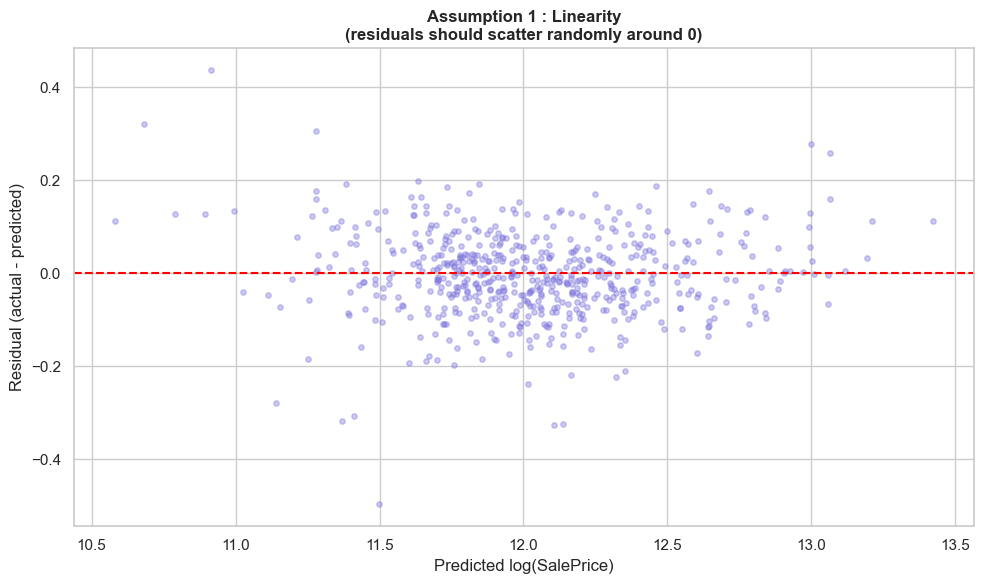

── How to read this plot ────────────────────
  ✓ PASS : dots look like a random cloud, no visible curve/pattern
  ✗ FAIL : dots form a U-shape, arc, or funnel shape

  Look at your plot above and judge it visually —
  linearity doesn't have a single number/test like the others.


In [5]:
#  What it means: the relationship between X and y should be
#  a straight line, not curved.
#
#  How we check: plot residuals vs predicted values.
#  → GOOD  : dots scattered randomly around the horizontal 0 line
#  → BAD   : dots form a curve (U-shape, arc, funnel) → relationship
#            is not actually linear, model is missing something
# ────────────────────────────────────────────────────────────────
 
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.4, color='#7F77DD', s=15)
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted log(SalePrice)')
plt.ylabel('Residual (actual - predicted)')
plt.title('Assumption 1 : Linearity\n(residuals should scatter randomly around 0)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\16_linearity.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
print("── How to read this plot ────────────────────")
print("  ✓ PASS : dots look like a random cloud, no visible curve/pattern")
print("  ✗ FAIL : dots form a U-shape, arc, or funnel shape")
print("\n  Look at your plot above and judge it visually —")
print("  linearity doesn't have a single number/test like the others.")
 

In [7]:
#
#  What it means: one house's error shouldn't predict another
#  house's error. Errors should be independent of each other.
#
#  How we check: Durbin-Watson test (a single number)
#    DW ≈ 2.0   → no autocorrelation (GOOD, this is what we want)
#    DW < 1.5   → positive autocorrelation (residuals are similar
#                 to their neighbors — BAD)
#    DW > 2.5   → negative autocorrelation (residuals zigzag — BAD)
# ────────────────────────────────────────────────────────────────
 
dw_stat = durbin_watson(residuals)
 
print("── Assumption 2 : Independence (Durbin-Watson) ──")
print(f"  Durbin-Watson statistic : {dw_stat:.4f}")
print()
 
if 1.5 <= dw_stat <= 2.5:
    print("  ✓ PASS — value is close to 2.0, residuals look independent")
else:
    print("  ✗ WARNING — value is far from 2.0, some autocorrelation present")
 
print("\n  Note: this test matters most for TIME SERIES data.")
print("  For house price data (not sequential in time), a DW near 2")
print("  simply confirms no hidden ordering issue snuck into your rows.")
 
 
 

── Assumption 2 : Independence (Durbin-Watson) ──
  Durbin-Watson statistic : 2.0656

  ✓ PASS — value is close to 2.0, residuals look independent

  Note: this test matters most for TIME SERIES data.
  For house price data (not sequential in time), a DW near 2
  simply confirms no hidden ordering issue snuck into your rows.


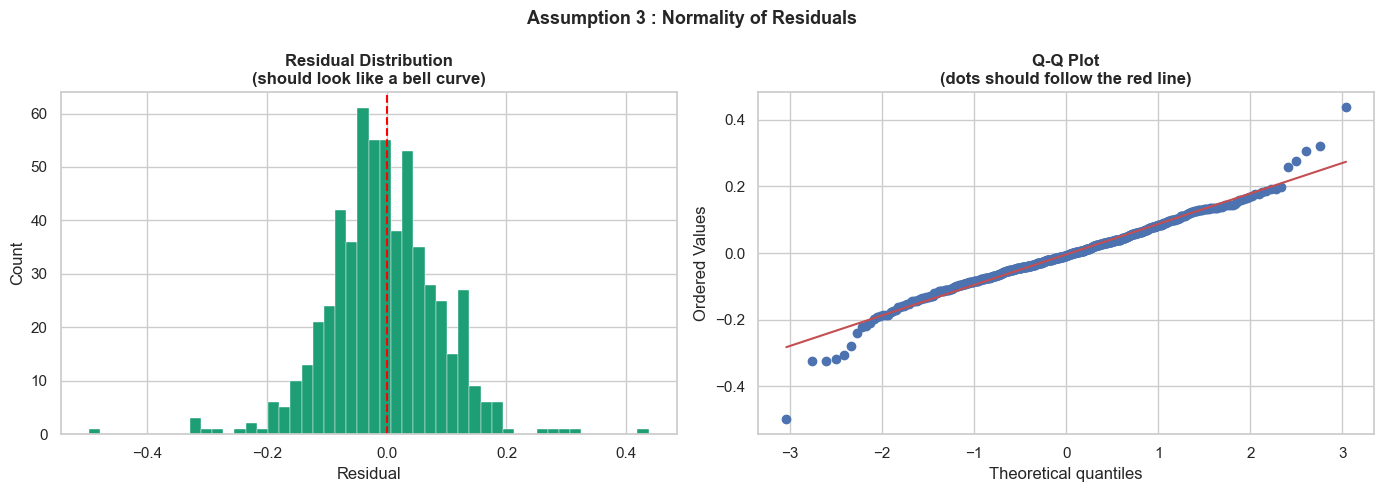

── Assumption 3 : Normality (Shapiro-Wilk Test) ──
  Statistic : 0.9748
  p-value   : 0.000000

  ✗ FAIL (statistically) — p < 0.05
  → This is COMMON with large datasets (n > 1000).
  → Check the Q-Q plot visually — minor tail deviations are normal
    and usually not a serious problem for prediction accuracy.


In [8]:
#  What it means: residuals (errors) should follow a normal
#  (bell curve) distribution.
#
#  How we check TWO ways:
#    1. Q-Q Plot (visual)   : dots should follow the diagonal line
#    2. Shapiro-Wilk test   : statistical test
#         p-value > 0.05  → residuals ARE normal (good)
#         p-value < 0.05  → residuals are NOT normal (technically fails)
#
#  Note: Shapiro-Wilk is very strict with large datasets — it will
#  often say "not normal" even when residuals look fine visually.
#  Always check the Q-Q plot too, don't rely on the p-value alone.
# ────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# --- Plot 1 : Histogram of residuals ---
axes[0].hist(residuals, bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].set_title('Residual Distribution\n(should look like a bell curve)', fontweight='bold')
 
# --- Plot 2 : Q-Q Plot ---
# This compares your residuals against a theoretical perfect normal distribution.
# If dots sit ON the red line → residuals are normal.
# If dots curve away at the ends → residuals have "heavy tails" (more extreme values)
stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot\n(dots should follow the red line)', fontweight='bold')
 
plt.suptitle('Assumption 3 : Normality of Residuals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\17_normality.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
# --- Shapiro-Wilk Test ---
# sample if dataset is large — Shapiro-Wilk has a 5000-row limit
sample_residuals = residuals if len(residuals) <= 5000 else np.random.choice(residuals, 5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_residuals)
 
print("── Assumption 3 : Normality (Shapiro-Wilk Test) ──")
print(f"  Statistic : {shapiro_stat:.4f}")
print(f"  p-value   : {shapiro_p:.6f}")
print()
if shapiro_p > 0.05:
    print("  ✓ PASS — p > 0.05, residuals are normally distributed")
else:
    print("  ✗ FAIL (statistically) — p < 0.05")
    print("  → This is COMMON with large datasets (n > 1000).")
    print("  → Check the Q-Q plot visually — minor tail deviations are normal")
    print("    and usually not a serious problem for prediction accuracy.")
 

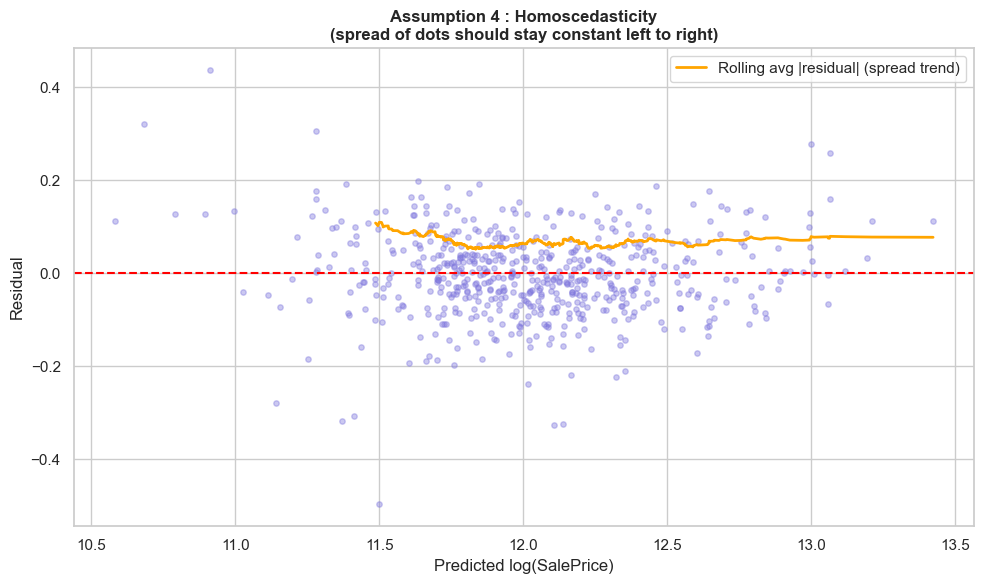

── Assumption 4 : Homoscedasticity (Breusch-Pagan) ──
  LM Statistic : 289.6530
  p-value      : 0.000003

  ✗ FAIL — p < 0.05, heteroscedasticity detected
  → Common in price data: expensive houses are often harder
    to predict precisely than cheap ones (naturally more spread)
  → Log-transforming SalePrice (already done in Phase 3) usually
    reduces this — but some residual heteroscedasticity is normal


In [9]:
#
#  What it means: the SPREAD of residuals should stay roughly
#  constant across all predicted values.
#
#  Opposite = HETEROSCEDASTICITY: errors get bigger (or smaller)
#  as predictions get bigger — looks like a "funnel" shape.
#
#  How we check TWO ways:
#    1. Same residuals vs predicted plot (look for funnel shape)
#    2. Breusch-Pagan test
#         p-value > 0.05 → homoscedastic (GOOD, constant variance)
#         p-value < 0.05 → heteroscedastic (BAD, variance changes)
# ────────────────────────────────────────────────────────────────
 
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.4, color='#7F77DD', s=15)
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
 
# Add a rolling "spread" line to help visualise funnel shapes
sorted_idx = np.argsort(y_pred)
window = 50
rolling_std = pd.Series(np.abs(residuals)[sorted_idx]).rolling(window).mean()
plt.plot(np.sort(y_pred), rolling_std, color='orange', linewidth=2,
         label='Rolling avg |residual| (spread trend)')
 
plt.xlabel('Predicted log(SalePrice)')
plt.ylabel('Residual')
plt.title('Assumption 4 : Homoscedasticity\n(spread of dots should stay constant left to right)',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\18_homoscedasticity.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
# --- Breusch-Pagan Test ---
# Needs the actual X matrix (with intercept column added)
X_test_with_const = np.hstack([np.ones((X_test.shape[0], 1)), X_test.values])
bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(residuals, X_test_with_const)
 
print("── Assumption 4 : Homoscedasticity (Breusch-Pagan) ──")
print(f"  LM Statistic : {bp_stat:.4f}")
print(f"  p-value      : {bp_p:.6f}")
print()
if bp_p > 0.05:
    print("  ✓ PASS — p > 0.05, variance is constant (homoscedastic)")
else:
    print("  ✗ FAIL — p < 0.05, heteroscedasticity detected")
    print("  → Common in price data: expensive houses are often harder")
    print("    to predict precisely than cheap ones (naturally more spread)")
    print("  → Log-transforming SalePrice (already done in Phase 3) usually")
    print("    reduces this — but some residual heteroscedasticity is normal")
 

In [10]:
# We already tested this fully in Phase 5 with VIF.
# Just printing a quick reminder here so this notebook has all 5
# LINE assumptions in one place.
 
print("── Assumption 5 : No Multicollinearity ──────")
print("  Already tested in Phase 5 using VIF (Variance Inflation Factor)")
print("  Result: 62 out of 188 features had VIF > 10")
print("  Status: ✗ VIOLATED — will be addressed with Ridge regression in Phase 8")

── Assumption 5 : No Multicollinearity ──────
  Already tested in Phase 5 using VIF (Variance Inflation Factor)
  Result: 62 out of 188 features had VIF > 10
  Status: ✗ VIOLATED — will be addressed with Ridge regression in Phase 8


In [11]:
print("=" * 58)
print("        LINE ASSUMPTIONS — FINAL SUMMARY")
print("=" * 58)
print(f"  L — Linearity         : check plot visually (Cell 3)")
print(f"  I — Independence      : DW = {dw_stat:.3f}  →  {'PASS' if 1.5<=dw_stat<=2.5 else 'WARNING'}")
print(f"  N — Normality          : p = {shapiro_p:.4f}  →  {'PASS' if shapiro_p>0.05 else 'FAIL (large-n effect, check Q-Q plot)'}")
print(f"  E — Equal Variance     : p = {bp_p:.4f}  →  {'PASS' if bp_p>0.05 else 'FAIL (mild heteroscedasticity)'}")
print(f"      No Multicollinearity : 62/188 features VIF>10  →  VIOLATED")
print("=" * 58)
print()
print("What this means for your project:")
print("  → Your model's PREDICTIONS remain valid and usable (R²=0.95)")
print("  → Violations affect how much you can TRUST individual")
print("    coefficients and statistical confidence intervals")
print("  → This is exactly why Phase 7 (feature selection) and")
print("    Phase 8 (Ridge/Lasso) exist — they directly fix these issues")
print("=" * 58)

        LINE ASSUMPTIONS — FINAL SUMMARY
  L — Linearity         : check plot visually (Cell 3)
  I — Independence      : DW = 2.066  →  PASS
  N — Normality          : p = 0.0000  →  FAIL (large-n effect, check Q-Q plot)
  E — Equal Variance     : p = 0.0000  →  FAIL (mild heteroscedasticity)
      No Multicollinearity : 62/188 features VIF>10  →  VIOLATED

What this means for your project:
  → Your model's PREDICTIONS remain valid and usable (R²=0.95)
  → Violations affect how much you can TRUST individual
    coefficients and statistical confidence intervals
  → This is exactly why Phase 7 (feature selection) and
    Phase 8 (Ridge/Lasso) exist — they directly fix these issues
